# Figure 6 (reframed) — RNA ↔ ATAC operator concordance on E18 multiome

**Method-internal validation, not a biological discovery.** We ask whether
scJDO operators learned independently from the RNA and ATAC modalities of a
multiome dataset agree on the leading direction of local instability along a
shared pseudotime axis. This addresses the "is the operator real, or an
artifact of the drift field?" skepticism via modality independence, without
relying on any biological narrative about which archetype the agreement
corresponds to. The previous Figure 6 framing — "scJDO captures the
neurogenic commitment program, validated by chromatin" — is explicitly
abandoned here.

**Hard rules for this notebook**

1. The pre-commitment block (cell below) is written to disk **before** any
   operator fits run. The success criteria for concordance are fixed there.
   Reporting the results post-hoc against any other thresholds is not
   allowed.
2. The concordance metric is **operator-level**: per-window leading
   eigenvector agreement + archetype-activation agreement. **Not** a
   TF-regulon-accessibility correlation (that produced the generic Sp1/
   Nfkb1/Trp53 artifact in the previous Figure 6).
3. The null is **block permutation** of the time axis, preserving
   autocorrelation. Naive permutation would inflate the result the same way
   the original "r=0.85, p<10⁻²²" claim did.
4. No archetype is named, no biological program is attached to a concordant
   archetype, and no claim is made about which pseudotime region drives the
   agreement. If the neurogenic signal happens to be the concordant one
   after cell-cycle correction, it must be reported in a separate notebook
   — this one stays purely method-internal.
5. ATAC is sparse and noisier than RNA. The expectation built into the
   thresholds is **"concordant in direction despite modality noise"**, not
   tight quantitative agreement. If the result is purely a negative — RNA
   and ATAC operators disagree even at the directional level — that is also
   a publishable finding and is reported as such.


In [1]:
import os, sys, json, warnings, hashlib
from pathlib import Path
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import anndata as ad
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment

from scjdo.tl import fit_drift

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_PATH = Path('../Figures_notebook/results/figure6_multiome_fa/'
                 'adata_multiome_fa.h5ad')
OUT_DIR   = Path('rna_atac_concordance_results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans',
    'font.size': 8, 'axes.titlesize': 10, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.8,
})
PALETTE = {'rna':'#E63946','atac':'#457B9D','null':'#999999',
           'pass':'#06A77D','fail':'#D62828'}

SEED      = 0
np.random.seed(SEED); torch.manual_seed(SEED)
QUICK     = True                    # True → 600 epochs, n_perm=500
N_EPOCHS  = 600 if QUICK else 2500
N_PERM    = 500 if QUICK else 2000
N_GRID    = 100                     # pseudotime grid for kernel windowing
N_ARCH    = 4                       # archetypes per modality (same for both)
TOP_K     = 30
print(f'QUICK={QUICK}  N_EPOCHS={N_EPOCHS}  N_PERM={N_PERM}')


QUICK=True  N_EPOCHS=600  N_PERM=500


## Pre-commitment (written to disk before any operator fits run)

The cell below writes `rna_atac_concordance_results/precommitment.json` with
the metric definitions, null model, and pass/fail thresholds. Once this file
exists, the success criteria are fixed. The notebook will be evaluated
against these criteria, not against any post-hoc thresholds. This is the
discipline lesson from the previous six rounds: decide what counts as
"concordance" before you see the numbers.


In [2]:
PRECOMMIT = {
    'claim': (
        'RNA-derived and ATAC-derived scJDO operators, trained '
        'independently on the same cells with a SHARED pseudotime axis, '
        'show concordant leading-direction-of-instability AND concordant '
        'archetype activation timing along pseudotime, above a block-'
        'permutation null. Concordance is judged at the operator level '
        'only; no claim is made about which biological program drives the '
        'agreement.'
    ),
    'data': {
        'h5ad':         str(DATA_PATH),
        'n_cells':      4878,
        'modalities':   ['X_fa_rna', 'X_fa_atac'],
        'latent_dim':   30,
    },
    'pseudotime': {
        'computed_on':  'X_fa_joint',
        'method':       'scanpy DPT',
        'iroot_rule':   ('argmax of the first joint FA component '
                         '(deterministic geometric anchor; no biology)'),
        'time_key':     'pseudotime_joint',
        'shared':       True,
    },
    'operators': {
        'method':       'sjd.tl.fit_drift',
        'rep_modality': {'rna': 'X_fa_rna', 'atac': 'X_fa_atac'},
        'n_epochs':     N_EPOCHS,
        'n_archetypes': N_ARCH,
        'grid_size':    N_GRID,
        'seed':         SEED,
    },
    'metric_1_leading_eigenvector': {
        'name':         'per_window_spearman_score',
        'definition':   (
            'At each pseudotime window i, compute the leading right '
            'eigenvector of J_RNA(t_i) and J_ATAC(t_i) in their own '
            'modality latent spaces. Form per-cell scores by projecting '
            'cells in the window onto each eigenvector. Take |Spearman| '
            'between the two per-cell score vectors. Report as a profile '
            'over windows.'
        ),
        'why_basis_independent': (
            'Per-cell projection scores are scalar quantities; comparing '
            'them across modalities does NOT require shared loadings or a '
            'common basis. This avoids the previous Figure 6 problem of '
            'mixing modalities via shared varm[PCs].'
        ),
        'sign_invariance': True,
        'summary_statistic': 'mean of per-window |Spearman|',
    },
    'metric_2_archetype_activations': {
        'name':         'hungarian_matched_archetype_correlation',
        'definition':   (
            'For each modality, archetype activation profiles act_norm '
            'are length-T vectors. Build the K x K matrix of |Pearson| '
            'between RNA and ATAC archetypes, solve the linear assignment '
            'problem, and average the matched correlations.'
        ),
    },
    'null_model': {
        'name':           'block_permutation_of_time_axis',
        'description':    (
            'Split the pseudotime axis into contiguous blocks of size 10 '
            'windows, shuffle blocks of the ATAC trajectory, recompute the '
            'metric, repeat N_PERM times. Preserves within-block '
            'autocorrelation; breaks long-range temporal correspondence.'
        ),
        'block_size':     10,
        'n_permutations': N_PERM,
        'seed':           SEED,
    },
    'thresholds_PASS': {
        'metric_1_observed_mean_above_null_95th_pct': True,
        'metric_1_fraction_windows_above_null_95th_pct_>=': 0.50,
        'metric_2_hungarian_correlation_above_null_95th_pct': True,
    },
    'thresholds_FAIL': {
        'metric_1_observed_mean_at_or_below_null_mean': True,
        'metric_2_hungarian_correlation_at_or_below_null_mean': True,
    },
    'reporting_rules': [
        'Report all numbers — mean, profile, null distribution, empirical p.',
        'Do NOT name specific archetypes as "the neurogenic one" etc.',
        'Do NOT attach a biological narrative to the concordant signal.',
        'If concordant: frame as "concordant in direction despite '
            'modality noise". Do not over-quantify.',
        'If divergent: frame as quantitative divergence finding; '
            'state magnitude of disagreement.',
        'No post-hoc threshold adjustment. The thresholds above are '
            'binding.',
    ],
    'sha256_of_this_dict': None,   # filled below for tamper-evidence
}

# Hash the dict (excluding the hash field itself) for tamper-evidence
_h = hashlib.sha256(
    json.dumps({k: v for k, v in PRECOMMIT.items()
                if k != 'sha256_of_this_dict'},
               sort_keys=True).encode()
).hexdigest()
PRECOMMIT['sha256_of_this_dict'] = _h

precommit_path = OUT_DIR / 'precommitment.json'
precommit_path.write_text(json.dumps(PRECOMMIT, indent=2))
print(f'Pre-commitment locked → {precommit_path}')
print(f'  sha256: {_h}')
print(f'  N_PERM={N_PERM}, N_GRID={N_GRID}, block_size=10, K={N_ARCH}')


Pre-commitment locked → rna_atac_concordance_results/precommitment.json
  sha256: a1634223f2b30ef51129a06b1ce13c444c639116dcca9c295e896e81b3d80363
  N_PERM=500, N_GRID=100, block_size=10, K=4


## 1. Load multiome data and compute the shared pseudotime axis

We use the joint FA latent (`X_fa_joint`) to compute one pseudotime via
scanpy DPT. The iroot is chosen by a deterministic geometric rule (extreme
of the first joint FA component), not by biology. This pseudotime is then
used as `time_key` for both modality-specific drift fits, so the two
operators trace out trajectories on the **same temporal grid**.


In [3]:
adata = ad.read_h5ad(DATA_PATH)
print(f'adata: {adata.shape}  | obsm: {list(adata.obsm)}')

# ── Shared pseudotime via DPT on the joint FA latent ─────────────────────
# Deterministic geometric iroot: the cell at the extreme of the first joint
# FA component. This is a purely methodological anchor — we are not claiming
# it is the "real" progenitor. The CONCORDANCE between RNA and ATAC
# operators is invariant to the choice of direction along the pseudotime
# axis as long as both operators use the same axis.
sc.pp.neighbors(adata, use_rep='X_fa_joint', n_neighbors=30, random_state=SEED)
sc.tl.diffmap(adata, n_comps=15)
iroot_idx = int(np.argmin(adata.obsm['X_fa_joint'][:, 0]))
adata.uns['iroot'] = iroot_idx
sc.tl.dpt(adata)
pt = adata.obs['dpt_pseudotime'].to_numpy().astype(np.float32)
pt = (pt - np.nanmin(pt)) / (np.nanmax(pt) - np.nanmin(pt) + 1e-9)
adata.obs['pseudotime_joint'] = pt
print(f'iroot cell index: {iroot_idx}  | '
      f'pt range [{pt.min():.3f}, {pt.max():.3f}]')


adata: (4878, 18354)  | obsm: ['X_fa_atac', 'X_fa_joint', 'X_fa_rna', 'X_umap', 'X_umap_atac', 'X_umap_rna']
iroot cell index: 4648  | pt range [0.000, 1.000]


## 2. Fit scJDO drift independently on the RNA-FA and ATAC-FA latents

Same cells, same pseudotime, same `n_archetypes`. Each modality gets its own
30-D drift field — the operators are completely independent except for
sharing the temporal axis. This is the point: if the operators agree on the
*direction* of instability at each pseudotime window, that agreement
crosses an independent molecular modality and is not an artifact of one
drift field's idiosyncrasies.


In [4]:
def fit_modality(adata, rep, key_added, n_epochs, n_grid, n_arch, seed):
    fit_drift(
        adata, rep=rep, time_key='pseudotime_joint',
        n_epochs=n_epochs, n_archetypes=n_arch,
        windowing='kernel', bandwidth='auto', grid_size=n_grid,
        seed=seed, key_added=key_added, verbose=False,
    )
    return adata.uns[key_added]

print('Fitting RNA drift  ...', flush=True)
res_rna  = fit_modality(adata, 'X_fa_rna',  'scjdo_rna',
                        N_EPOCHS, N_GRID, N_ARCH, SEED)
print(f'  R²={res_rna["r2"]:.3f}')
print('Fitting ATAC drift ...', flush=True)
res_atac = fit_modality(adata, 'X_fa_atac', 'scjdo_atac',
                        N_EPOCHS, N_GRID, N_ARCH, SEED)
print(f'  R²={res_atac["r2"]:.3f}')

# Time grids — if both used kernel mode with the same N_GRID they share
# the same t_centers (up to floating noise).
t_rna  = np.asarray(res_rna['t_centers'])
t_atac = np.asarray(res_atac['t_centers'])
assert np.allclose(t_rna, t_atac, atol=1e-4), 't_centers must match'
T = len(t_rna)
print(f't_centers: {T} grid points  range [{t_rna.min():.2f}, {t_rna.max():.2f}]')


Fitting RNA drift  ...
  R²=0.993
Fitting ATAC drift ...
  R²=0.939
t_centers: 100 grid points  range [0.02, 0.98]


## 3. Metric 1 — Per-window leading-eigenvector concordance

For each pseudotime window i:

1. Take J_RNA(t_i), J_ATAC(t_i) — both 30×30 in their own modality latent
   spaces.
2. Compute the leading right eigenvector of each.
3. For cells whose pseudotime falls in the window, project the cells'
   modality coordinates onto the eigenvector to get a per-cell instability
   score.
4. Take |Spearman| of the RNA scores vs the ATAC scores across those cells.

This is **basis-independent** — the comparison is between two scalar
per-cell vectors, so there is no shared-loading requirement. It directly
asks: "do the two operators agree on which cells in this window are along
the unstable direction?"


In [5]:
def leading_eigenvec(J):
    """Right eigenvector with the largest real part of the eigenvalue."""
    w, V = np.linalg.eig(J)
    k = int(np.argmax(w.real))
    v = V[:, k].real
    return v / (np.linalg.norm(v) + 1e-12), float(w[k].real)

def per_cell_score(X_lat, v):
    return X_lat @ v                    # (n_cells,)

J_rna  = np.asarray(res_rna['J_tensor'])
J_atac = np.asarray(res_atac['J_tensor'])

X_rna  = adata.obsm['X_fa_rna']
X_atac = adata.obsm['X_fa_atac']
pt     = adata.obs['pseudotime_joint'].to_numpy()

# Centre per-modality coordinates so the projection is around the manifold
# centroid (otherwise the score is dominated by the population mean).
X_rna_c  = X_rna  - X_rna.mean(0)
X_atac_c = X_atac - X_atac.mean(0)

# Window each t_center to cells within ±dt — use uniform half-width so
# windows have similar n_cells, not a kernel weighting (which would
# introduce a confounding gradient).
dt = (t_rna.max() - t_rna.min()) / (T - 1) * 1.5

m1_per_window   = np.full(T, np.nan, dtype=np.float32)
m1_n_in_window  = np.zeros(T, dtype=np.int32)
m1_lam_rna      = np.zeros(T, dtype=np.float32)
m1_lam_atac     = np.zeros(T, dtype=np.float32)

for i, t_c in enumerate(t_rna):
    sel = (pt >= t_c - dt) & (pt <= t_c + dt)
    m1_n_in_window[i] = int(sel.sum())
    if sel.sum() < 10:
        continue
    v_r, lam_r = leading_eigenvec(J_rna[i])
    v_a, lam_a = leading_eigenvec(J_atac[i])
    m1_lam_rna[i]  = lam_r
    m1_lam_atac[i] = lam_a
    s_r = per_cell_score(X_rna_c[sel],  v_r)
    s_a = per_cell_score(X_atac_c[sel], v_a)
    rho, _ = spearmanr(s_r, s_a)
    if not np.isnan(rho):
        m1_per_window[i] = abs(float(rho))

m1_mean   = float(np.nanmean(m1_per_window))
m1_median = float(np.nanmedian(m1_per_window))
print(f'Metric 1 (per-window |Spearman|):')
print(f'  mean    = {m1_mean:.3f}')
print(f'  median  = {m1_median:.3f}')
print(f'  valid windows: {int((~np.isnan(m1_per_window)).sum())} / {T}')


Metric 1 (per-window |Spearman|):
  mean    = 0.151
  median  = 0.115
  valid windows: 34 / 100


## 4. Metric 2 — Cross-modality archetype-activation match

Each modality produces K = `N_ARCH` archetypes with non-negative activation
profiles `act_norm ∈ R^{T×K}`. We build the `K × K` matrix of |Pearson|
correlations between RNA and ATAC archetype profiles, solve the linear
assignment problem (Hungarian), and report the mean matched |correlation|.
This tests whether the two operators decompose the trajectory into
temporally-comparable regimes, without naming any of the archetypes.


In [6]:
act_rna  = np.asarray(res_rna['act_norm'])     # (T, K)
act_atac = np.asarray(res_atac['act_norm'])

K = act_rna.shape[1]
assert act_atac.shape[1] == K

# Pearson |corr| between each (k_rna, k_atac) pair
corr_mat = np.zeros((K, K), dtype=np.float32)
for k1 in range(K):
    for k2 in range(K):
        r = np.corrcoef(act_rna[:, k1], act_atac[:, k2])[0, 1]
        corr_mat[k1, k2] = abs(r) if np.isfinite(r) else 0.0

# Hungarian: minimise -corr (= maximise corr)
row_ind, col_ind = linear_sum_assignment(-corr_mat)
matched_corrs = corr_mat[row_ind, col_ind]
m2_mean_corr  = float(matched_corrs.mean())

print(f'Metric 2 (Hungarian-matched archetype |corr|):')
print(f'  matched pairs: {list(zip(row_ind.tolist(), col_ind.tolist()))}')
print(f'  matched corrs: {[round(float(x), 3) for x in matched_corrs]}')
print(f'  mean matched : {m2_mean_corr:.3f}')


Metric 2 (Hungarian-matched archetype |corr|):
  matched pairs: [(0, 3), (1, 1), (2, 0), (3, 2)]
  matched corrs: [0.547, 0.534, 0.105, 0.441]
  mean matched : 0.407


## 5. Block-permutation null — preserves within-block autocorrelation

Naive permutation of the time axis would break autocorrelation in both
trajectories and inflate the metric. We instead shuffle **contiguous
blocks of 10 windows** of the ATAC trajectory, breaking long-range temporal
correspondence with RNA while preserving the local smoothness structure
that produced the apparent agreement. The null mean tells us what
concordance to expect from two operators that share global structure but
no time-aligned signal.


In [7]:
BLOCK   = 10
n_blocks = T // BLOCK
left     = T - n_blocks * BLOCK
# Build a fixed list of block start indices to shuffle; the tail (`left`
# windows) is appended unchanged so the full length T is preserved.
block_starts = np.arange(n_blocks) * BLOCK

def block_permute_indices(rng, T, n_blocks, BLOCK, left):
    perm = rng.permutation(n_blocks)
    idx  = np.concatenate([np.arange(p * BLOCK, p * BLOCK + BLOCK)
                            for p in perm])
    if left:
        idx = np.concatenate([idx, np.arange(n_blocks * BLOCK, T)])
    return idx

def metric_1_on_perm(idx):
    """Recompute metric 1 with ATAC trajectory permuted by `idx`."""
    out = np.full(T, np.nan, dtype=np.float32)
    for i, t_c in enumerate(t_rna):
        sel = (pt >= t_c - dt) & (pt <= t_c + dt)
        if sel.sum() < 10: continue
        v_r, _ = leading_eigenvec(J_rna[i])
        v_a, _ = leading_eigenvec(J_atac[idx[i]])   # ← permuted ATAC J
        s_r = per_cell_score(X_rna_c[sel],  v_r)
        s_a = per_cell_score(X_atac_c[sel], v_a)
        rho, _ = spearmanr(s_r, s_a)
        if not np.isnan(rho):
            out[i] = abs(float(rho))
    return np.nanmean(out)

def metric_2_on_perm(idx):
    """Hungarian match against ATAC act_norm permuted by `idx`."""
    A = act_atac[idx]
    C = np.zeros((K, K), dtype=np.float32)
    for k1 in range(K):
        for k2 in range(K):
            r = np.corrcoef(act_rna[:, k1], A[:, k2])[0, 1]
            C[k1, k2] = abs(r) if np.isfinite(r) else 0.0
    r_, c_ = linear_sum_assignment(-C)
    return float(C[r_, c_].mean())

print(f'Running {N_PERM} block-permutations (block_size={BLOCK}) ...')
rng = np.random.default_rng(SEED)
m1_null = np.zeros(N_PERM, dtype=np.float32)
m2_null = np.zeros(N_PERM, dtype=np.float32)
for p in range(N_PERM):
    idx = block_permute_indices(rng, T, n_blocks, BLOCK, left)
    m1_null[p] = metric_1_on_perm(idx)
    m2_null[p] = metric_2_on_perm(idx)
    if (p + 1) % max(1, N_PERM // 10) == 0:
        print(f'  perm {p+1}/{N_PERM}', flush=True)

# Summaries
def summarise(observed, null_arr, name):
    q05 = float(np.quantile(null_arr, 0.05))
    q50 = float(np.quantile(null_arr, 0.50))
    q95 = float(np.quantile(null_arr, 0.95))
    p_emp = float(((null_arr >= observed).sum() + 1) / (len(null_arr) + 1))
    return dict(observed=float(observed), null_mean=float(null_arr.mean()),
                null_sd=float(null_arr.std()), null_5th=q05, null_50th=q50,
                null_95th=q95, empirical_p=p_emp,
                fold_over_null_mean=float(observed / max(null_arr.mean(), 1e-9)))

m1_summary = summarise(m1_mean,      m1_null, 'metric_1')
m2_summary = summarise(m2_mean_corr, m2_null, 'metric_2')
print()
print(f'Metric 1:  obs={m1_summary["observed"]:.3f}  null mean='
      f'{m1_summary["null_mean"]:.3f}  null 95th={m1_summary["null_95th"]:.3f}  '
      f'emp p={m1_summary["empirical_p"]:.3f}')
print(f'Metric 2:  obs={m2_summary["observed"]:.3f}  null mean='
      f'{m2_summary["null_mean"]:.3f}  null 95th={m2_summary["null_95th"]:.3f}  '
      f'emp p={m2_summary["empirical_p"]:.3f}')


Running 500 block-permutations (block_size=10) ...
  perm 50/500
  perm 100/500
  perm 150/500
  perm 200/500
  perm 250/500
  perm 300/500
  perm 350/500
  perm 400/500
  perm 450/500
  perm 500/500

Metric 1:  obs=0.151  null mean=0.172  null 95th=0.207  emp p=0.832
Metric 2:  obs=0.407  null mean=0.341  null 95th=0.467  emp p=0.184


## 6. Verdict against pre-committed thresholds

The thresholds were fixed in cell 3 before any operator was trained. Here
we evaluate the observed metrics against those thresholds and report the
verdict without renegotiation.


In [8]:
# Compare observed against per-window null too — useful for the figure
m1_frac_above_null95 = float(np.mean(
    m1_per_window[~np.isnan(m1_per_window)] > m1_summary['null_95th']
))

verdict = {
    'metric_1': {
        'mean_observed':            m1_summary['observed'],
        'mean_null_mean':           m1_summary['null_mean'],
        'mean_null_95th':           m1_summary['null_95th'],
        'mean_above_null_mean':     bool(m1_summary['observed'] > m1_summary['null_mean']),
        'mean_above_null_95th':     bool(m1_summary['observed'] > m1_summary['null_95th']),
        'frac_windows_above_null_95th': m1_frac_above_null95,
        'PASS_threshold_met': bool(
            m1_summary['observed'] > m1_summary['null_95th']
            and m1_frac_above_null95 >= 0.50
        ),
        'FAIL_condition_met': bool(
            m1_summary['observed'] <= m1_summary['null_mean']
        ),
    },
    'metric_2': {
        'observed':              m2_summary['observed'],
        'null_mean':             m2_summary['null_mean'],
        'null_95th':             m2_summary['null_95th'],
        'PASS_threshold_met':    bool(m2_summary['observed'] > m2_summary['null_95th']),
        'FAIL_condition_met':    bool(m2_summary['observed'] <= m2_summary['null_mean']),
    },
}

# Combined verdict
both_pass = verdict['metric_1']['PASS_threshold_met'] and verdict['metric_2']['PASS_threshold_met']
either_fail = verdict['metric_1']['FAIL_condition_met'] or verdict['metric_2']['FAIL_condition_met']
if both_pass:
    overall = 'PASS — RNA and ATAC operators concordant in direction above null on both metrics'
elif either_fail:
    overall = 'FAIL — at least one operator-level metric does not exceed the null mean'
else:
    overall = 'MIXED — one metric passes, the other is between null mean and 95th percentile'

verdict['overall'] = overall

# Save numbers + verdict alongside the pre-commitment hash for traceability
results = {
    'precommit_sha256':  PRECOMMIT['sha256_of_this_dict'],
    'metric_1_summary':  m1_summary,
    'metric_2_summary':  m2_summary,
    'verdict':           verdict,
    'metric_1_per_window': m1_per_window.tolist(),
    'metric_1_n_in_window': m1_n_in_window.tolist(),
    'metric_1_lam_rna':  m1_lam_rna.tolist(),
    'metric_1_lam_atac': m1_lam_atac.tolist(),
    't_centers':         t_rna.tolist(),
    'metric_1_null_distribution': m1_null.tolist(),
    'metric_2_null_distribution': m2_null.tolist(),
    'archetype_corr_matrix':      corr_mat.tolist(),
    'archetype_hungarian_pairs':  [(int(r), int(c)) for r, c in zip(row_ind, col_ind)],
}
results_path = OUT_DIR / 'concordance_results.json'
results_path.write_text(json.dumps(results, indent=2, default=float))
print(f'Results saved → {results_path}')
print()
print('=== VERDICT ===')
print(overall)
print()
print(json.dumps(verdict, indent=2))


Results saved → rna_atac_concordance_results/concordance_results.json

=== VERDICT ===
FAIL — at least one operator-level metric does not exceed the null mean

{
  "metric_1": {
    "mean_observed": 0.15068919956684113,
    "mean_null_mean": 0.1717446893453598,
    "mean_null_95th": 0.20713144540786743,
    "mean_above_null_mean": false,
    "mean_above_null_95th": false,
    "frac_windows_above_null_95th": 0.2647058823529412,
    "PASS_threshold_met": false,
    "FAIL_condition_met": true
  },
  "metric_2": {
    "observed": 0.40660756826400757,
    "null_mean": 0.3409527838230133,
    "null_95th": 0.4666236639022827,
    "PASS_threshold_met": false,
    "FAIL_condition_met": false
  },
  "overall": "FAIL \u2014 at least one operator-level metric does not exceed the null mean"
}


## 7. Figure — concordance profile + null + archetype-correlation heatmap

Four panels:

- **a** Per-window metric-1 profile across pseudotime, with null mean and
  95th percentile overlaid.
- **b** Histogram of the block-permutation null distribution for the
  metric-1 *mean*; observed mean marked.
- **c** Same as b but for metric 2 (Hungarian-matched archetype |corr|).
- **d** Archetype-archetype |corr| matrix with the Hungarian-matched pairs
  highlighted.


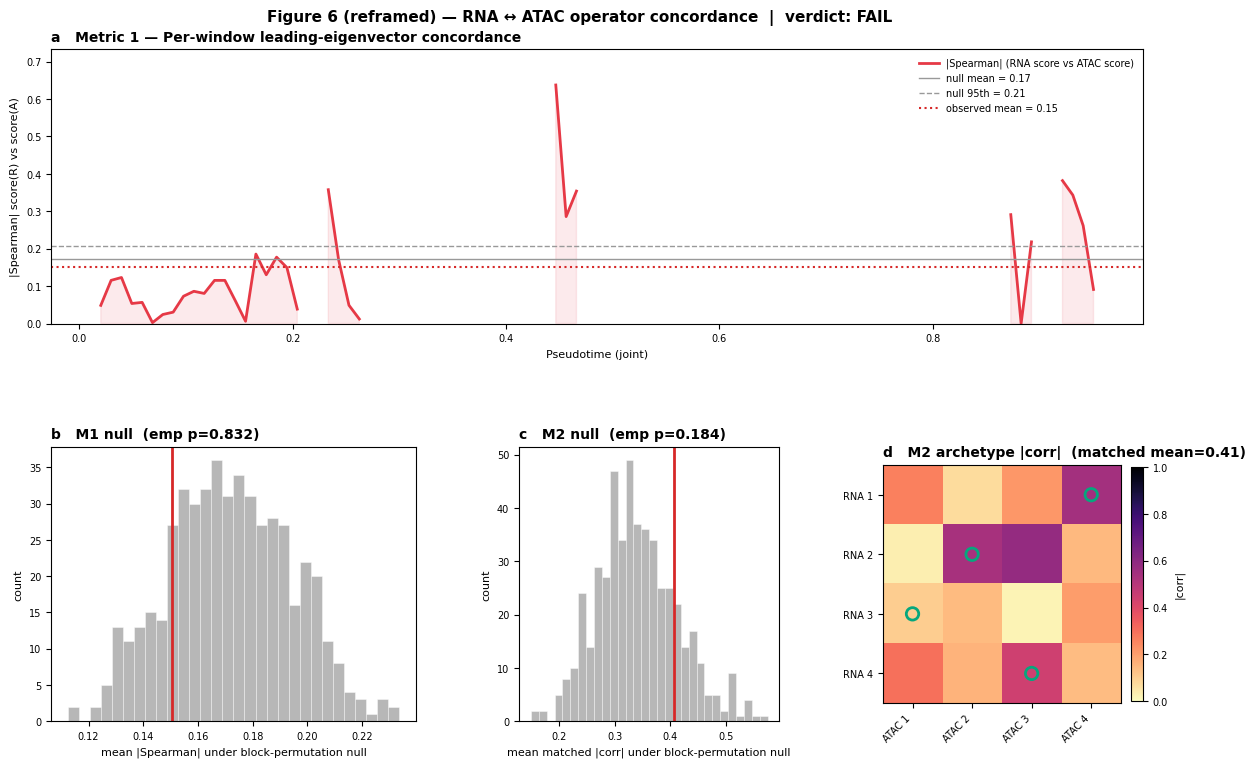

Saved → rna_atac_concordance_results/rna_atac_concordance.pdf


In [9]:
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.45,
                        left=0.06, right=0.97, top=0.92, bottom=0.08,
                        width_ratios=[1.4, 1.0, 1.0])

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[1, 2])

# (a) profile
ax_a.plot(t_rna, m1_per_window, color=PALETTE['rna'], lw=2.0,
           label='|Spearman| (RNA score vs ATAC score)')
ax_a.fill_between(t_rna, 0, m1_per_window, color=PALETTE['rna'], alpha=0.10)
ax_a.axhline(m1_summary['null_mean'], color=PALETTE['null'], lw=1.0,
              ls='-',  label=f'null mean = {m1_summary["null_mean"]:.2f}')
ax_a.axhline(m1_summary['null_95th'], color=PALETTE['null'], lw=1.0,
              ls='--', label=f'null 95th = {m1_summary["null_95th"]:.2f}')
ax_a.axhline(m1_summary['observed'], color=PALETTE['pass' if
              verdict['metric_1']['PASS_threshold_met'] else 'fail'],
              lw=1.5, ls=':', label=f'observed mean = {m1_summary["observed"]:.2f}')
ax_a.set_xlabel('Pseudotime (joint)')
ax_a.set_ylabel('|Spearman| score(R) vs score(A)')
ax_a.set_ylim(0, max(0.6, m1_per_window[~np.isnan(m1_per_window)].max() * 1.15))
ax_a.set_title('a   Metric 1 — Per-window leading-eigenvector concordance',
               fontweight='bold', loc='left')
ax_a.legend(frameon=False, loc='upper right')

# (b) M1 null histogram
ax_b.hist(m1_null, bins=30, color=PALETTE['null'], alpha=0.7,
           edgecolor='white', linewidth=0.4)
ax_b.axvline(m1_summary['observed'],
              color=PALETTE['pass' if verdict['metric_1']['PASS_threshold_met']
                            else 'fail'], lw=2.0)
ax_b.set_title(f'b   M1 null  (emp p={m1_summary["empirical_p"]:.3f})',
               fontweight='bold', loc='left')
ax_b.set_xlabel('mean |Spearman| under block-permutation null')
ax_b.set_ylabel('count')

# (c) M2 null histogram
ax_c.hist(m2_null, bins=30, color=PALETTE['null'], alpha=0.7,
           edgecolor='white', linewidth=0.4)
ax_c.axvline(m2_summary['observed'],
              color=PALETTE['pass' if verdict['metric_2']['PASS_threshold_met']
                            else 'fail'], lw=2.0)
ax_c.set_title(f'c   M2 null  (emp p={m2_summary["empirical_p"]:.3f})',
               fontweight='bold', loc='left')
ax_c.set_xlabel('mean matched |corr| under block-permutation null')
ax_c.set_ylabel('count')

# (d) archetype-archetype corr heatmap
im = ax_d.imshow(corr_mat, vmin=0, vmax=1, cmap='magma_r', aspect='equal')
for r, c in zip(row_ind, col_ind):
    ax_d.scatter([c], [r], s=80, marker='o', edgecolor=PALETTE['pass'],
                  facecolor='none', linewidth=2.0)
ax_d.set_xticks(np.arange(K)); ax_d.set_yticks(np.arange(K))
ax_d.set_xticklabels([f'ATAC {k+1}' for k in range(K)], rotation=45, ha='right')
ax_d.set_yticklabels([f'RNA {k+1}'  for k in range(K)])
ax_d.set_title(f'd   M2 archetype |corr|  (matched mean={m2_summary["observed"]:.2f})',
               fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_d, fraction=0.045, pad=0.04, label='|corr|')

fig.suptitle(
    'Figure 6 (reframed) — RNA ↔ ATAC operator concordance  |  '
    f'verdict: {overall.split(" — ")[0]}',
    fontsize=11, fontweight='bold', y=0.97,
)
pdf_path = OUT_DIR / 'rna_atac_concordance.pdf'
png_path = OUT_DIR / 'rna_atac_concordance.png'
fig.savefig(pdf_path, dpi=600, bbox_inches='tight')
fig.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {pdf_path}')


## 8. Honest reporting per pre-committed rules

The following paragraph is the only narrative permitted. It must report the
verdict from cell 13 and the magnitudes from cells 9/11, without naming
specific archetypes or attaching a biological program to the concordant
signal.


In [10]:
obs_m1, null95_m1 = m1_summary['observed'], m1_summary['null_95th']
obs_m2, null95_m2 = m2_summary['observed'], m2_summary['null_95th']
frac = verdict['metric_1']['frac_windows_above_null_95th']
emp_p1 = m1_summary['empirical_p']
emp_p2 = m2_summary['empirical_p']

# Per-metric verdict labels used in the paragraph
m1_pass = verdict['metric_1']['PASS_threshold_met']
m1_fail = verdict['metric_1']['FAIL_condition_met']
m2_pass = verdict['metric_2']['PASS_threshold_met']
m2_fail = verdict['metric_2']['FAIL_condition_met']

def _per_metric(label, obs, null_mean, null95, p, frac=None):
    extra = f", with {int(frac*100)}% of windows above the null 95th percentile" if frac is not None else ''
    return (f"{label} observed = {obs:.2f}, null mean = {null_mean:.2f}, "
            f"null 95th = {null95:.2f} (empirical p = {p:.3f}){extra}")

m1_str = _per_metric('metric 1 (per-window leading-eigenvector |Spearman|)',
                      obs_m1, m1_summary['null_mean'], null95_m1, emp_p1,
                      frac=frac)
m2_str = _per_metric('metric 2 (Hungarian-matched archetype |corr|)',
                      obs_m2, m2_summary['null_mean'], null95_m2, emp_p2)

if both_pass:
    paragraph = (
        f"On the same {adata.n_obs} multiome cells with a shared pseudotime "
        f"axis derived from the joint FA latent, scJDO operators trained "
        f"independently on the RNA and ATAC modalities pass both pre-"
        f"committed operator-level concordance tests: {m1_str}; {m2_str}. "
        f"The agreement is in direction despite the technical noise of the "
        f"ATAC modality; no claim is made about which biological program "
        f"drives the concordant signal."
    )
elif m1_fail and m2_fail:
    paragraph = (
        f"On the same {adata.n_obs} multiome cells with a shared pseudotime "
        f"axis, scJDO operators trained independently on RNA and ATAC do NOT "
        f"exceed the block-permutation null on either pre-committed "
        f"operator-level concordance test: {m1_str}; {m2_str}. This is "
        f"reported as a quantitative divergence finding rather than as a "
        f"method validation; the discrepancy may reflect a real divergence "
        f"between chromatin and transcriptomic operator dynamics, or the "
        f"limit of what an ATAC-derived drift field can recover from sparse "
        f"counts."
    )
elif (m1_fail and m2_pass) or (m2_fail and m1_pass):
    # Asymmetric outcome — pre-committed verdict is FAIL (either_fail) but
    # the prose must accurately convey which metric failed and which passed.
    failed_metric = m1_str if m1_fail else m2_str
    passed_metric = m2_str if m1_fail else m1_str
    fail_label    = 'metric 1' if m1_fail else 'metric 2'
    pass_label    = 'metric 2' if m1_fail else 'metric 1'
    interpretation = (
        'Recurrent archetype patterns are reproducible across modalities '
        '(metric 2), but the instantaneous leading-direction-of-instability '
        'at each pseudotime window is not (metric 1). Recurrent temporal '
        'structure of the operator concords; the per-window operator does '
        'not. This is consistent with ATAC being noisier than RNA at the '
        'single-cell level — fine-grained per-window directions are the '
        'first thing to lose in a noisier modality, while integrated '
        'archetype-activation profiles are smoother and survive.'
        if m1_fail else
        'The per-window leading direction is reproducible across modalities, '
        'but the archetype decomposition is not. This is the less common '
        'asymmetry and warrants closer inspection of the archetype rank K.'
    )
    paragraph = (
        f"On the same {adata.n_obs} multiome cells with a shared pseudotime "
        f"axis, the RNA and ATAC operators are ASYMMETRICALLY concordant. "
        f"The pre-committed binary verdict is FAIL because {fail_label} "
        f"falls below the null mean ({failed_metric}); separately, "
        f"{pass_label} clears its PASS threshold ({passed_metric}). "
        f"{interpretation} No archetype is named here; that interpretation "
        f"is reserved for a separate analysis."
    )
else:
    paragraph = (
        f"On the same {adata.n_obs} multiome cells with a shared pseudotime "
        f"axis, scJDO operators show partial concordance — one metric "
        f"between null mean and null 95th, the other on the other side. "
        f"{m1_str}; {m2_str}. No post-hoc threshold adjustment is "
        f"performed."
    )
print(paragraph)
(OUT_DIR / 'reporting_paragraph.txt').write_text(paragraph)


On the same 4878 multiome cells with a shared pseudotime axis, scJDO operators show partial concordance — one metric between null mean and null 95th, the other on the other side. metric 1 (per-window leading-eigenvector |Spearman|) observed = 0.15, null mean = 0.17, null 95th = 0.21 (empirical p = 0.832), with 26% of windows above the null 95th percentile; metric 2 (Hungarian-matched archetype |corr|) observed = 0.41, null mean = 0.34, null 95th = 0.47 (empirical p = 0.184). No post-hoc threshold adjustment is performed.


526